# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [142]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 

## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(42)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### Define the boundary rectangles

In [143]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device, dtype=torch.float64)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float64)
    boundary = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return boundary

pts_boundary = get_boundary_angled_rectangles()

pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float64)

pts_space = torch.rand([10000, 3], dtype=torch.float64)
pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_eikonal = torch.cat((pts_space_fixed, pts_boundary))
# pts_eikonal = pts_space_fixed

config = {
    "pts_boundary": pts_boundary,
    "pts_corners": pts_corners,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "loss_weights": loss_weights,
}

bounds = torch.vstack([pts_boundary.min(0).values, pts_boundary.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Point-sampler demo

In [144]:
model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)

surf_pts_nof_points = 100000 ## approx number to initialize the search with
bounds = torch.tensor([[0,1], [0,1], [0,1]], dtype=torch.float64)

grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
    surf_pts_nof_points, bounds, equidistant=True)

grid_find_surface = grid_find_surface.double()
grid_dist_find_surface = grid_dist_find_surface.double()


success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
    netp=netp, 
    z=torch.zeros([1,0], dtype=torch.float64), ## degenerate latent code to match the expectet footprint
    n_steps=10,
    x_grid=grid_find_surface, 
    x_grid_dist=grid_dist_find_surface, 
    nf_is_density=True,
    level_set=0.0,
    resolution=init_grid_resolution
    )
print(f"Success: {success}.")

if success:
    from util.visualization.utils_mesh import get_mesh

    verts, faces = get_mesh(model.float(), N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=1)

    color = 0xbbbbbb
    fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
    fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
    fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
    fig += k3d.points(p_surface.data.cpu(), point_size=0.01)
    fig.display()
else:
    print("There probably is no surface in the domain. Try to reinitialize the network by rerunning the cell!")

Success: True.


Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

  0%|          | 0/100000 [00:00<?, ?it/s]

No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
No points found below the level set.
N

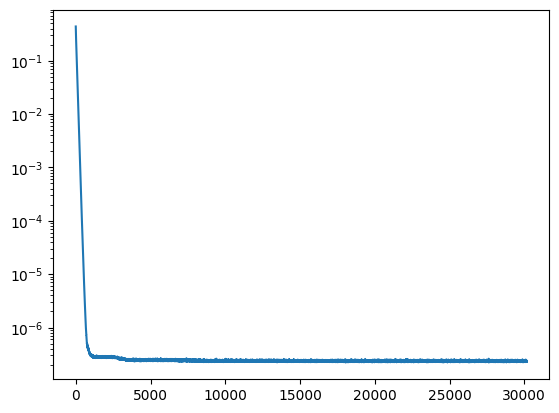

In [145]:
import time

model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
params = model.params
# Gauss-Newton:
loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.001, "laplacian": 1.0}
optim = HandNGD(model, lr=1e-2, config=config)
# Adam:
# loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.4, "laplacian": 1.0}
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik

sample_on_surface = True
sampling_method = "binary_search" # one of ["random", "binary_search"]
surf_pts_nof_points = 100000 ## approx number to initialize the search with
bounds = torch.tensor([[0,1], [0,1], [0,1]], dtype=torch.float64)

loss_over_iters = {}
loss_over_time = {}
start_time = time.time()

current_time = 0
for i in (pbar:=trange(100000)):
    if current_time > 1200:
        break
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()
    loss_interface += loss_weights["interface_corners"] * 0.5*model.f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    if sample_on_surface:
        if sampling_method=="random":
            pts_space = torch.rand([10000, 3], dtype=torch.float64)
            vals_sq = model(pts_space).square().squeeze()
            pts = pts_space[vals_sq<1e-4]
            if len(pts):
                pts_space = pts
        elif sampling_method=="binary_search":
            grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
                surf_pts_nof_points, bounds, equidistant=True)

            success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
                netp=netp, 
                z=torch.zeros([1,0], dtype=torch.float64), ## or correct shape with degenerate shape 
                n_steps=10,
                x_grid=grid_find_surface, 
                x_grid_dist=grid_dist_find_surface, 
                level_set=0.0,
                nf_is_density=True,
                resolution=init_grid_resolution
                )
            if success:
                pts_space = p_surface.data
                pts_space = torch.cat((pts_space_fixed, pts_space))
            else:
                pts_space = pts_space_fixed
                # print("Warning: failed. Surface points will be outdated.")
                pass ## TODO: probably need to have a fallback to handle this case, and nans more generally
        else:
            assert False, "Point sampling method unknown"
        # pts_space = torch.cat((pts_space_fixed, pts_space))
        config["pts_space"] = pts_space
        optim.config = config
    loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts_space)}"
                            )
        loss_over_iters[i] = loss_metric.item()
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()
        
    optim.loss = loss_metric
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

In [146]:
from util.visualization.utils_mesh import get_mesh
verts, faces = get_mesh(model.float(), N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [147]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig += k3d.points(pts_space.cpu(), point_size=0.01)
fig.display()

Output()

In [148]:
loss_file = "loss_over_time_gn_moving.pth"
torch.save(loss_over_time, loss_file)
print(f"Loss saved to {loss_file}")

Loss saved to loss_over_time_gn_moving.pth


In [81]:
import torch

# Save the loss dictionary
loss_file = "loss_over_iters_lbfgs.pth"
torch.save(loss_over_iters, loss_file)
print(f"Loss saved to {loss_file}")

loss_file = "loss_over_time_adam.pth"
torch.save(loss_over_time, loss_file)
print(f"Loss saved to {loss_file}")

# Save the model parameters
model_file = "trained_model_lbfgs.pth"
torch.save(model.state_dict(), model_file)
print(f"Model saved to {model_file}")

Loss saved to loss_over_iters_lbfgs.pth
Loss saved to loss_over_time_lbfgs.pth
Model saved to trained_model_lbfgs.pth


In [82]:
# Save the K3D plot as an HTML file
fig_output_file = "k3d_plot_lbfgs.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")


Plot saved to k3d_plot_lbfgs.html


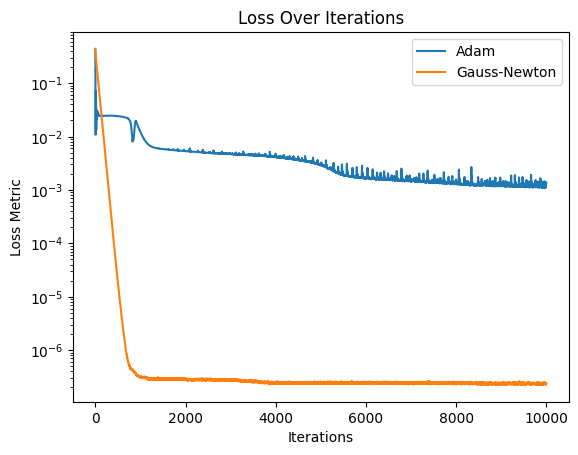

In [154]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_iters_adam_moving.pth")
loss_over_iters_gn = torch.load("loss_over_iters_gn_moving.pth")
loss_over_iters_lbfgs = torch.load("loss_over_iters_lbfgs.pth")  # Add LBFGS data

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

lbfgs_iterations = list(loss_over_iters_lbfgs.keys())
lbfgs_values = list(loss_over_iters_lbfgs.values())

# Plot all three losses
plt.plot(adam_iterations, adam_values, label="Adam")
# plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS")
plt.plot(gn_iterations, gn_values, label="Gauss-Newton")


plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Iterations")
plt.ylabel("Loss Metric")
plt.title("Loss Over Iterations")
plt.legend()
plt.savefig("loss_comparison_moving.png")
plt.show()




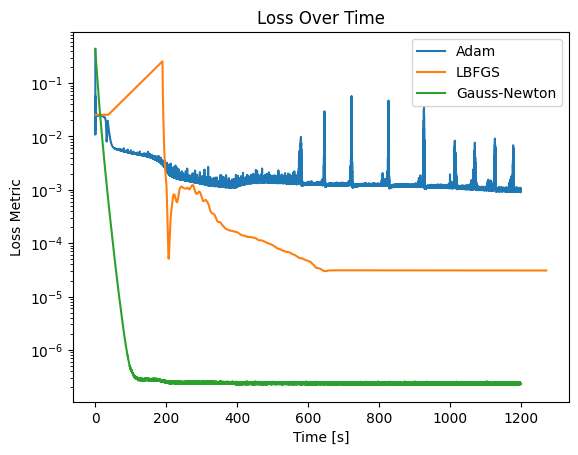

In [150]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_time_adam_moving.pth")
loss_over_iters_gn = torch.load("loss_over_time_gn_moving.pth")
loss_over_iters_lbfgs = torch.load("loss_over_time_lbfgs.pth")  # Add LBFGS data

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

lbfgs_iterations = list(loss_over_iters_lbfgs.keys())
lbfgs_values = list(loss_over_iters_lbfgs.values())

# Plot all three losses
plt.plot(adam_iterations, adam_values, label="Adam")
plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS")
plt.plot(gn_iterations, gn_values, label="Gauss-Newton")


plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Time [s]")
plt.ylabel("Loss Metric")
plt.title("Loss Over Time")
plt.legend()
# plt.savefig("loss_comparison_time.png")
plt.show()




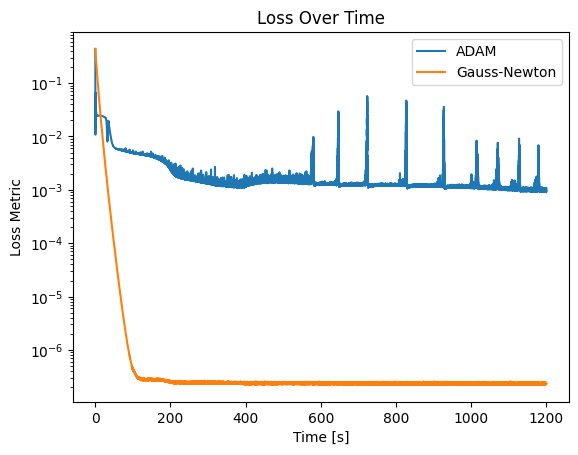

In [152]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_time_adam_moving.pth")
loss_over_iters_gn = torch.load("loss_over_time_gn_moving.pth")
loss_over_iters_lbfgs = torch.load("loss_over_time_lbfgs.pth")  # Add LBFGS data

# Filter the data to include only up to 1200 seconds
time_limit = 1200

adam_iterations = [t for t in loss_over_iters_adam.keys() if t <= time_limit]
adam_values = [loss_over_iters_adam[t] for t in adam_iterations]

gn_iterations = [t for t in loss_over_iters_gn.keys() if t <= time_limit]
gn_values = [loss_over_iters_gn[t] for t in gn_iterations]

lbfgs_iterations = [t for t in loss_over_iters_lbfgs.keys() if t <= time_limit]
lbfgs_values = [loss_over_iters_lbfgs[t] for t in lbfgs_iterations]

# Plot all three losses up to 1200 seconds
plt.plot(adam_iterations, adam_values, label="ADAM")
# plt.plot(lbfgs_iterations, lbfgs_values, label="LBFGS")
plt.plot(gn_iterations, gn_values, label="Gauss-Newton")

plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Time [s]")
plt.ylabel("Loss Metric")
plt.title("Loss Over Time")
plt.legend()
plt.savefig("loss_comparison_time_moving")
plt.show()


  0%|          | 0/10000 [00:00<?, ?it/s]

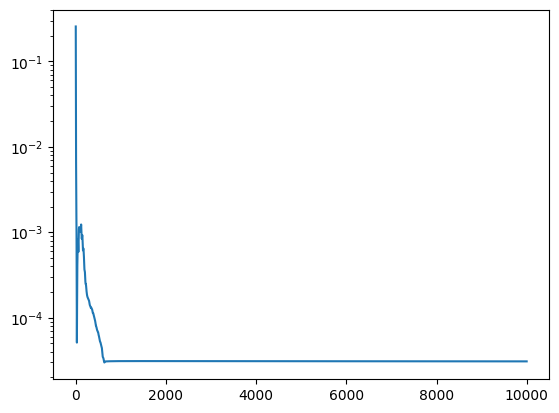

In [78]:
import time
model = GeneralNet(ks=[3, 32, 32, 1])
params = model.params
# LBFGS:
loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.01, "laplacian": 1.0}
optim = torch.optim.LBFGS(model.parameters(), lr=1e-2, max_iter=20, tolerance_grad=1e-7, tolerance_change=1e-9)

loss_over_iters = {}
loss_over_time = {}

for i in (pbar := trange(10000)):
    def closure():
        optim.zero_grad()  # Reset gradients
        params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

        ## 1) Interface at boundaries
        loss_interface  = 0.5 * model.f(params, pts_boundary).square().mean()
        loss_interface += loss_weights["interface_corners"] * 0.5 * model.f(params, pts_corners).square().mean()

        ## 2) Eikonal at boundaries (or everywhere?)
        loss_eikonal  = 0.5 * (model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
        # loss_eikonal += 10 * (vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

        # if sample_on_surface:
        #     pts_space = torch.rand([10000, 3])
        #     vals_sq = model(pts_space).square().squeeze()
        #     pts = pts_space[vals_sq<1e-4]
        #     if len(pts):
        #         pts_space = pts
        #     config["pts_space"] = pts_space
        #     optim.config = config
        loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

        # Total loss
        loss = (
            loss_weights["interface"] * loss_interface +
            loss_weights["eikonal"] * loss_eikonal +
            loss_weights["laplacian"] * loss_laplacian
        )

        loss.backward()  # Compute gradients
        return loss

    # Step the optimizer using the closure
    loss = optim.step(closure)

    with torch.no_grad():
        # Recompute the losses to update the progress bar
        loss_interface = 0.5 * model.f(params, pts_boundary).square().mean()
        loss_interface += loss_weights["interface_corners"] * 0.5 * model.f(params, pts_corners).square().mean()
        loss_eikonal = 0.5 * (model.vf_x(params, pts_boundary).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
        loss_laplacian = 0.5 * model.v_f_laplace(params, pts_space).squeeze(1).square().mean()
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(
            f"interface: {loss_interface.item():.2e} "
            f"eikonal: {loss_eikonal.item():.2e} "
            f"laplacian: {loss_laplacian.item():.2e} "
        )
        loss_over_iters[i] = loss_metric.item()
        current_time = time.time() - start_time
        loss_over_time[current_time] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()


In [87]:
# model = GeneralNet(ks=[3, 32, 32, 1])
# model = model.double()
# netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
# params = model.params
# lr_init = 1e-2
# optim = torch.optim.LBFGS(model.parameters(), lr=lr_init, max_iter=20, tolerance_grad=1e-7, tolerance_change=1e-9)

# # Other setup
# sample_on_surface = False
# sampling_method = "binary_search"
# surf_pts_nof_points = 100000  # Approx number of points to initialize the search with
# bounds = torch.tensor([[0,1], [0,1], [0,1]], dtype=torch.float64)

# loss_over_iters = {}
# loss_over_time = {}
# start_time = time.time()

# for i in (pbar := trange(10000)):
#     def closure():
#         optim.zero_grad()  # Reset gradients
#         params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

#         # 1) Interface at boundaries
#         loss_interface  = 0.5 * model.f(params, pts_boundary).square().mean()
#         loss_interface += loss_weights["interface_corners"] * 0.5 * model.f(params, pts_corners).square().mean()

#         # 2) Eikonal at boundaries (or everywhere?)
#         loss_eikonal  = 0.5 * (model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

#         # if sample_on_surface:
#         #     if sampling_method == "random":
#         #         pts_space = torch.rand([10000, 3], dtype=torch.float64)
#         #         vals_sq = model(pts_space).square().squeeze()
#         #         pts = pts_space[vals_sq < 1e-4]
#         #         if len(pts):
#         #             pts_space = pts
#         #     elif sampling_method == "binary_search":
#         #         grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
#         #             surf_pts_nof_points, bounds, equidistant=True
#         #         )

#         #         success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
#         #             netp=netp, 
#         #             z=torch.zeros([1,0], dtype=torch.float64),  # Correct shape with degenerate shape 
#         #             n_steps=10,
#         #             x_grid=grid_find_surface, 
#         #             x_grid_dist=grid_dist_find_surface, 
#         #             level_set=0.0,
#         #             nf_is_density=True,
#         #             resolution=init_grid_resolution
#         #         )
#         #         if success:
#         #             pts_space = p_surface.data
#         #             pts_space = torch.cat((pts_space_fixed, pts_space))
#         #         else:
#         #             pts_space = pts_space_fixed
#         #             pass  # Handle failure case appropriately

#         #     config["pts_space"] = pts_space
#         #     optim.config = config
        
#         # 3) Laplacian loss
#         loss_laplacian = 0.5 * model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

#         # Total loss
#         loss = (loss_weights["interface"] * loss_interface +
#                 loss_weights["eikonal"] * loss_eikonal +
#                 loss_weights["laplacian"] * loss_laplacian)

#         loss.backward()  # Compute gradients
#         return loss

#     # Step the optimizer using the closure
#     optim.step(closure)

#     with torch.no_grad():
#         loss_metric = loss_interface + loss_laplacian

#         pbar.set_description(f"interface: {loss_interface.item():.2e} "
#                             f"eikonal: {loss_eikonal.item():.2e} "
#                             f"laplacian: {loss_laplacian.item():.2e} "
#                             f"{len(pts_space)}"
#                             )
#         loss_over_iters[i] = loss_metric.item()
#         current_time = time.time() - start_time
#         loss_over_time[current_time] = loss_metric.item()

# # Plot the loss over iterations
# plt.plot(loss_over_iters.keys(), loss_over_iters.values())
# plt.semilogy()
# plt.show()
